# Jensen Alpha Momentum — 6M — Equal Weight

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('jensen_alpha', '6M', 'equal_weight')

## 1. Signal and portfolio rule

Daily stock excess return = alpha + beta × daily Nifty 50 excess return + residual. Both excess returns subtract the continuous liquid-fund daily return. OLS alpha is the ranking score over the fixed formation window; this is a trailing signal, not the strategy's subsequently realized alpha.

Each selected stock targets 1/N of pre-trade equity at a scheduled rebalance. If K<N qualify, target cash is (N−K)/N before charges; eligible stocks are not enlarged to 1/K. Sales precede purchases, which are reduced proportionally if charges or unfilled sales restrict available cash. Actual weights can therefore differ slightly from targets. Membership is rebuilt from current ranks without a retention buffer.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Daily alpha,MDTV (INR)
NSE:UFBL-EQ,0.0132,"42,078,240.59"
NSE:YASHO-EQ,0.0106,"37,220,195.50"
NSE:HFCL-EQ,0.0096,"3,688,024,397.99"
NSE:CUPID-EQ,0.0095,"2,261,224,535.95"
NSE:DIACABS-EQ,0.0092,"490,913,783.79"
NSE:AEROFLEX-EQ,0.0090,"644,982,030.67"
NSE:CONFIPET-EQ,0.0084,"129,439,974.50"
NSE:GRWRHITECH-EQ,0.0084,"309,324,106.35"
NSE:SETL-EQ,0.0083,"42,154,727.49"
NSE:SUVEN-EQ,0.0082,"120,651,212.30"


Symbol,Leg,Actual weight,Current selection,Execution status,Daily alpha,MDTV (INR)
NSE:UFBL-EQ,long,4.2%,True,selected,0.0132,"42,078,240.59"
NSE:YASHO-EQ,long,2.8%,True,selected,0.0106,"37,220,195.50"
NSE:HFCL-EQ,long,3.0%,True,selected,0.0096,"3,688,024,397.99"
NSE:CUPID-EQ,long,1.3%,True,selected,0.0095,"2,261,224,535.95"
NSE:DIACABS-EQ,long,1.3%,True,selected,0.0092,"490,913,783.79"
NSE:AEROFLEX-EQ,long,3.9%,True,selected,0.0090,"644,982,030.67"
NSE:CONFIPET-EQ,long,1.3%,True,selected,0.0084,"129,439,974.50"
NSE:GRWRHITECH-EQ,long,2.5%,True,selected,0.0084,"309,324,106.35"
NSE:SETL-EQ,long,1.3%,True,selected,0.0083,"42,154,727.49"
NSE:SUVEN-EQ,long,1.3%,True,selected,0.0082,"120,651,212.30"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:UFBL-EQ,2026-01-30,181.20,2026-07-31,701.65,287.2%


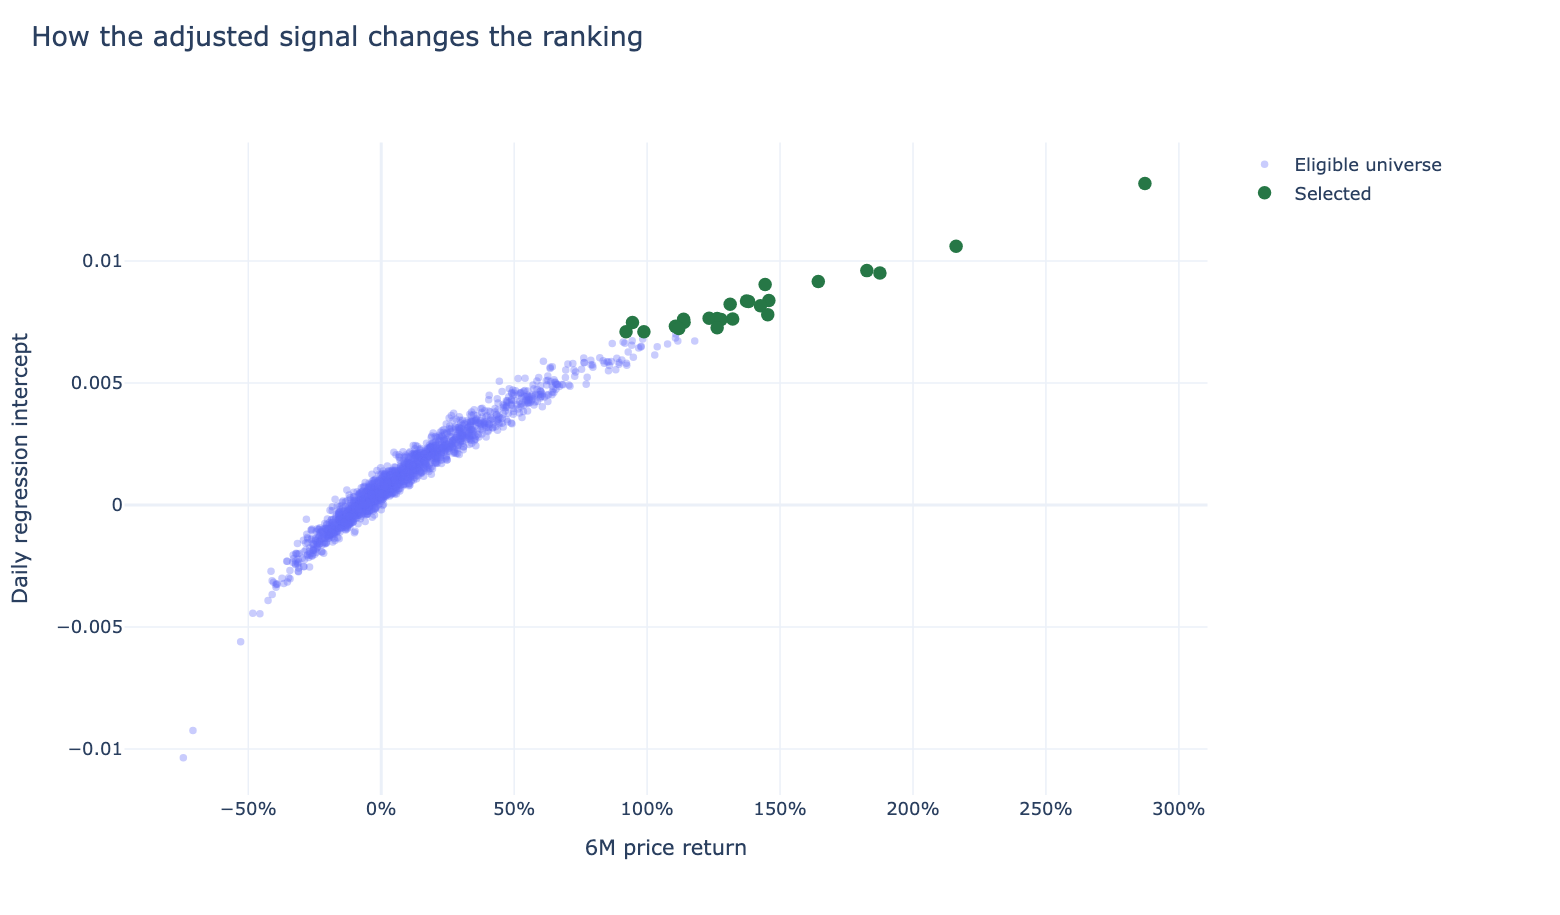

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Raw,After costs,Post-tax overlay
1M,12,11.8%,10.6%,9.3%
1M,24,14.0%,12.8%,11.2%
1M,50,16.5%,15.2%,13.4%
3M,12,7.5%,6.8%,5.6%
3M,24,12.1%,11.4%,9.7%
3M,50,14.4%,13.7%,11.9%
6M,12,2.2%,1.9%,1.4%
6M,24,9.0%,8.6%,7.2%
6M,50,11.6%,11.1%,9.6%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,9.3%,0.205,-81.8%,10.8%
1M,24,11.2%,0.283,-79.8%,11.5%
1M,50,13.4%,0.382,-78.8%,10.8%
3M,12,5.6%,0.067,-87.2%,12.3%
3M,24,9.7%,0.221,-80.2%,12.0%
3M,50,11.9%,0.312,-80.3%,11.3%
6M,12,1.4%,-0.173,-85.5%,11.1%
6M,24,7.2%,0.109,-80.5%,12.0%
6M,50,9.6%,0.214,-80.8%,11.8%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,18.0%,97.0%,1675
1M,24,17.9%,96.0%,1643
1M,50,17.5%,93.7%,1598
3M,12,20.4%,97.9%,2407
3M,24,17.7%,95.9%,1686
3M,50,17.8%,94.3%,1680
6M,12,19.2%,99.0%,4597
6M,24,18.7%,96.0%,1946
6M,50,18.2%,94.2%,1966


### CAGR

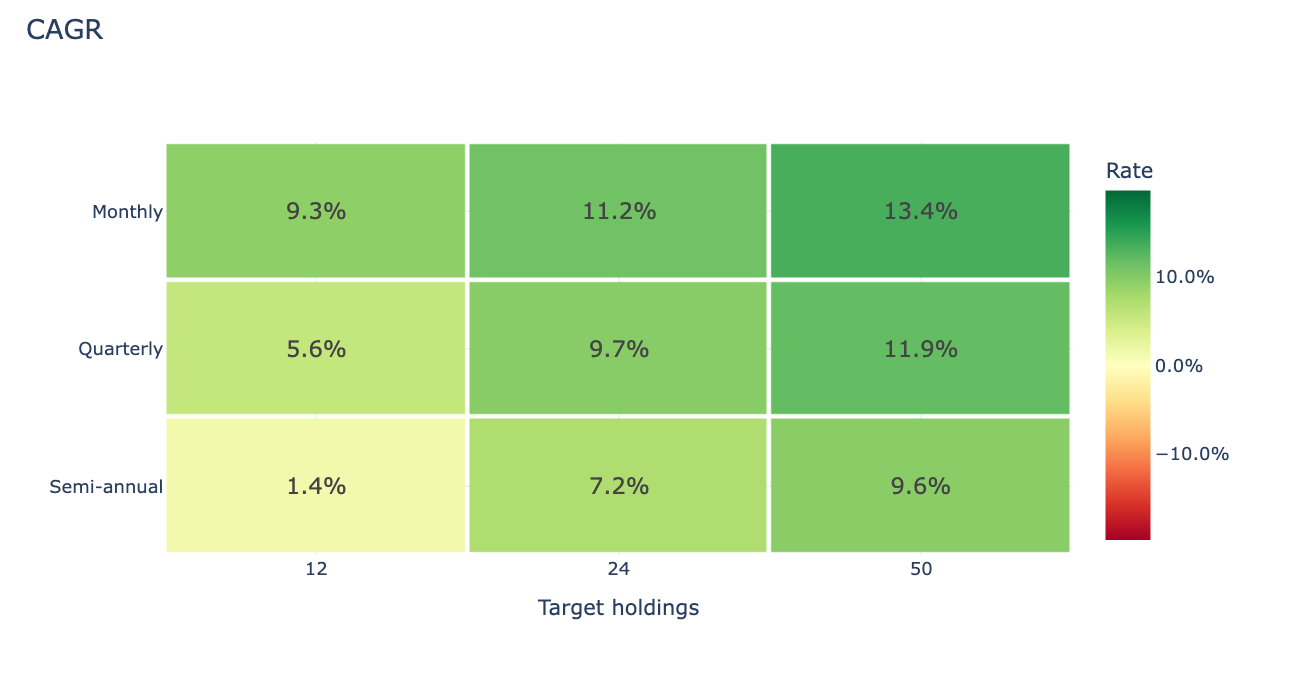

In [5]:
research.heatmap('cagr')

### Sharpe ratio

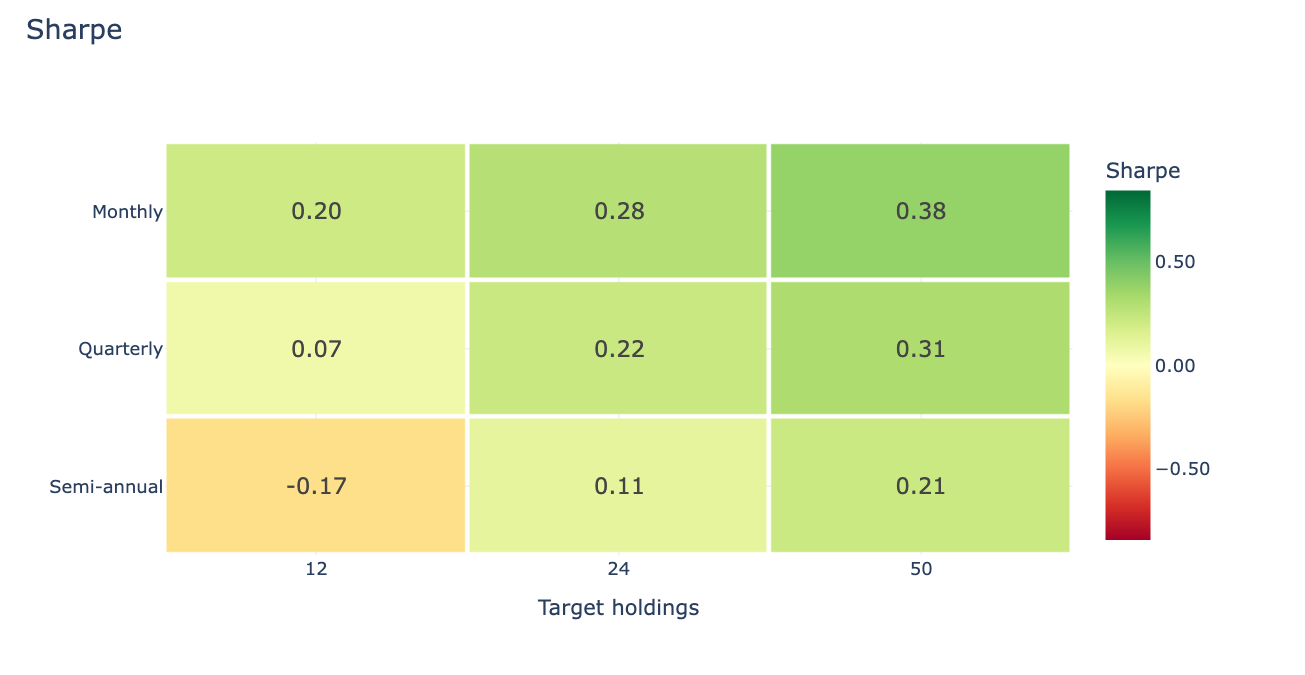

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

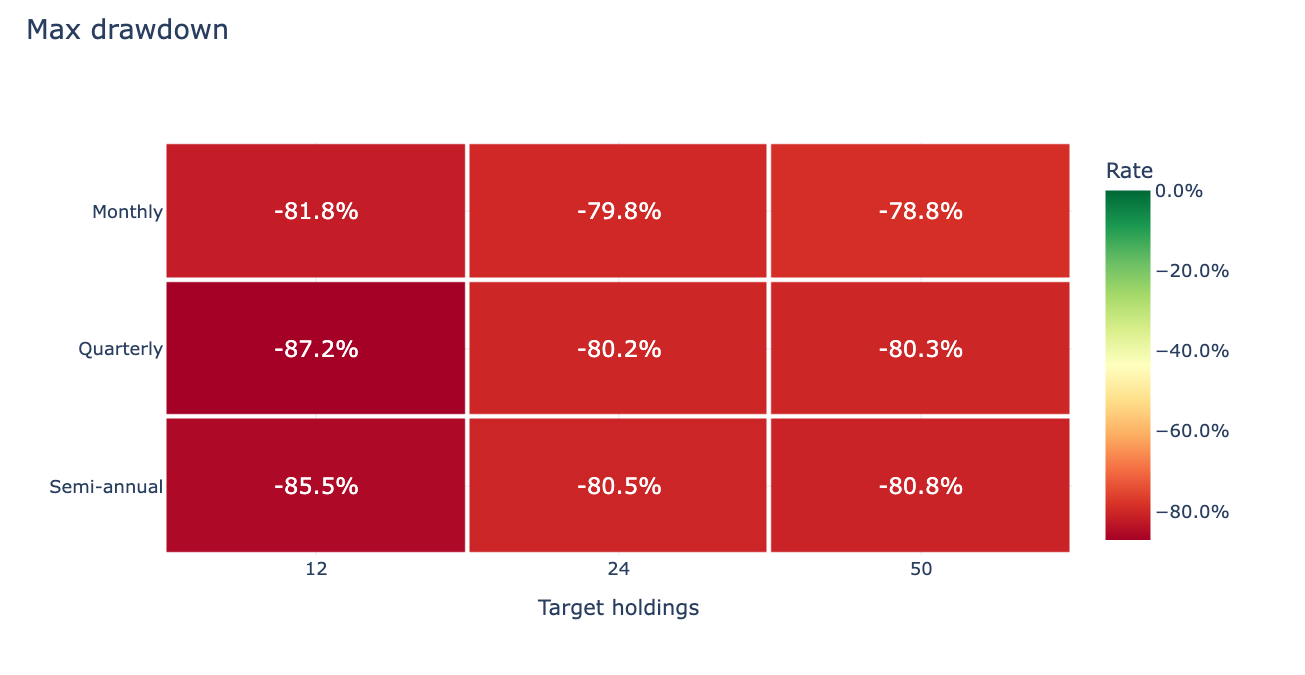

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

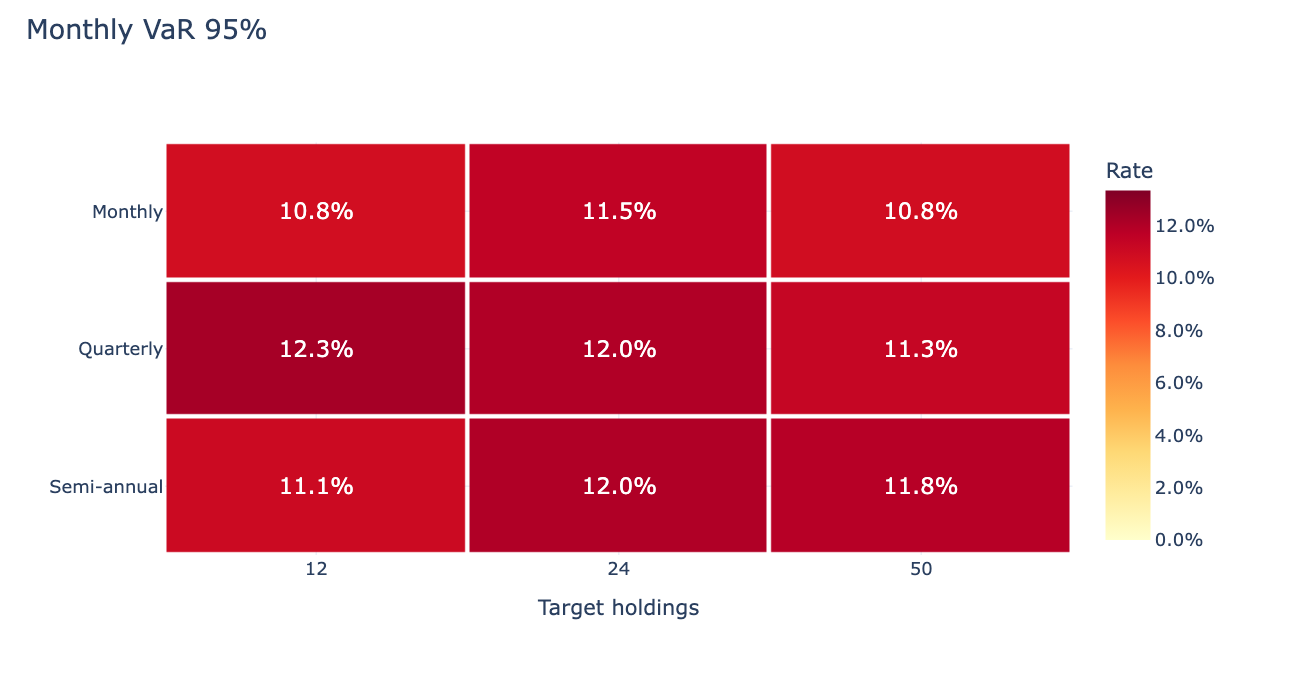

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

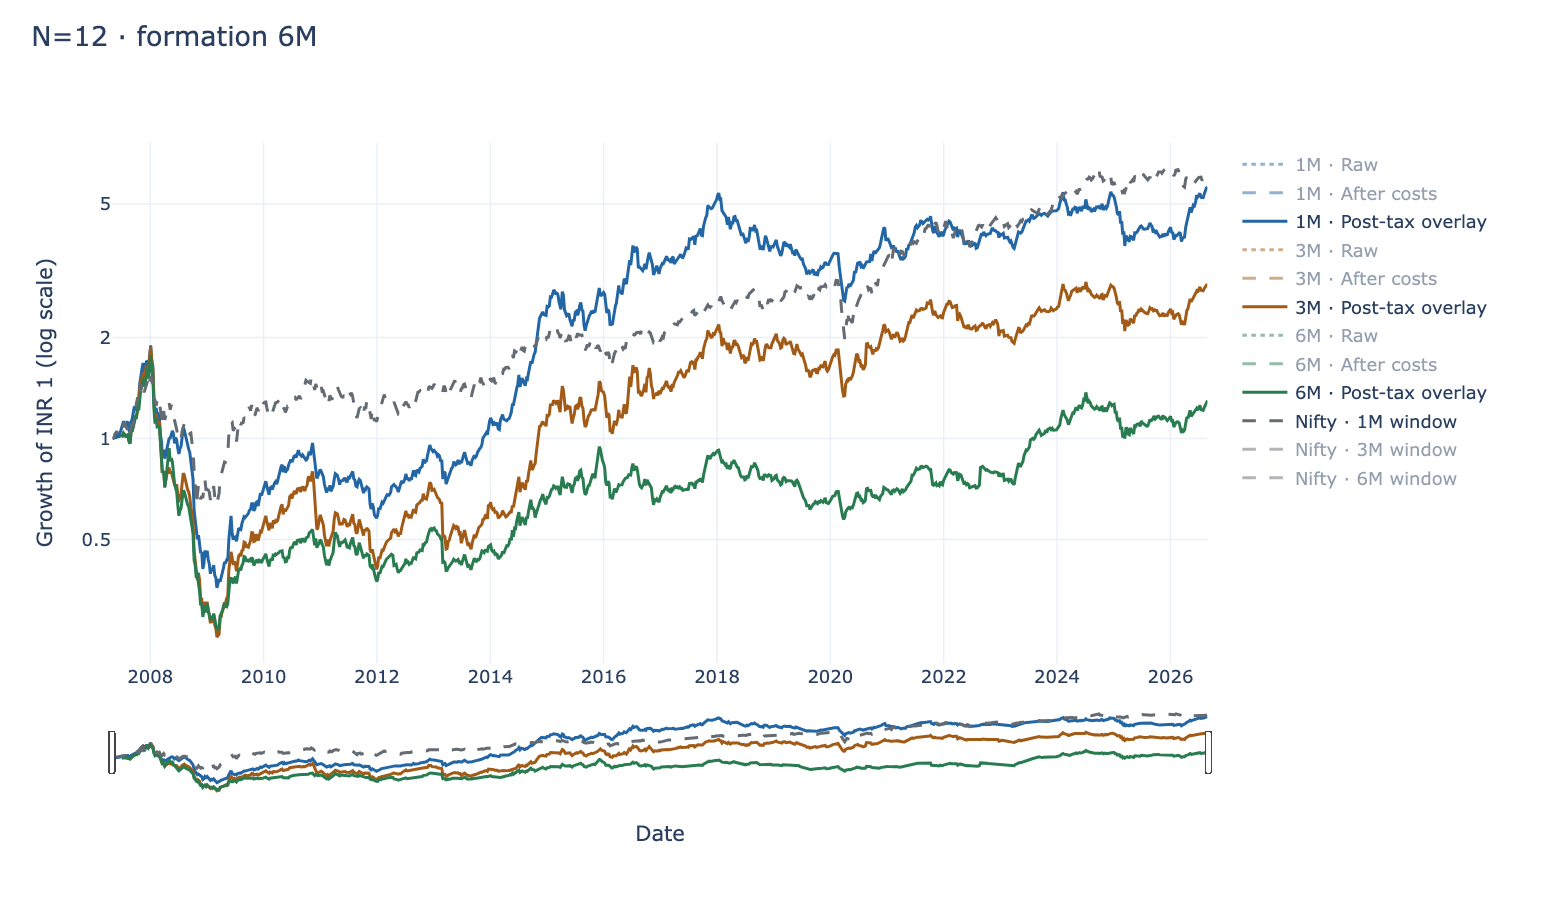

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,11.8%,0.305,-81.0%,10.7%
1M,After costs,10.6%,0.257,-81.3%,10.7%
1M,Post-tax overlay,9.3%,0.205,-81.8%,10.8%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,7.5%,0.137,-85.7%,12.3%
3M,After costs,6.8%,0.110,-85.8%,12.3%
3M,Post-tax overlay,5.6%,0.067,-87.2%,12.3%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,2.2%,-0.131,-84.0%,11.0%
6M,After costs,1.9%,-0.150,-84.1%,11.1%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,17.8%,96.3%,1654
1M,After costs,17.8%,96.6%,1673
3M,Raw,19.9%,97.1%,2092
3M,After costs,19.9%,97.3%,2377
6M,Raw,18.7%,99.0%,4597
6M,After costs,18.7%,99.0%,4597
1M,Post-tax overlay,18.0%,97.0%,1675
3M,Post-tax overlay,20.4%,97.9%,2407
6M,Post-tax overlay,19.2%,99.0%,4597
1M,Nifty 50 price,13.1%,92.4%,1520


In [9]:
research.equity(12)

### N=24

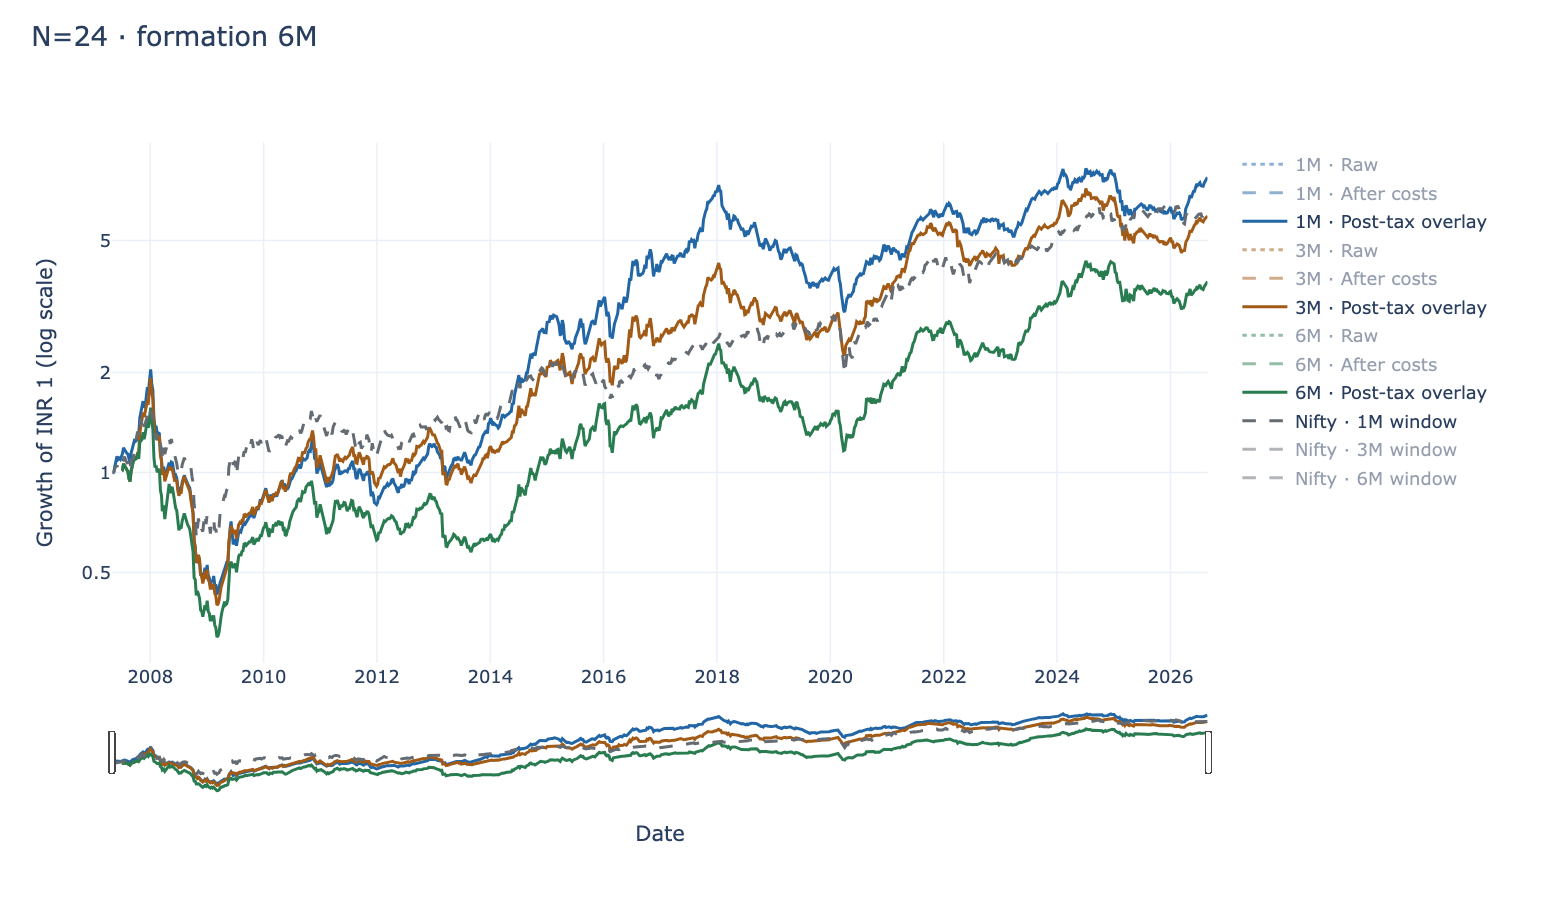

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,14.0%,0.404,-78.7%,10.9%
1M,After costs,12.8%,0.351,-79.1%,10.9%
1M,Post-tax overlay,11.2%,0.283,-79.8%,11.5%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,12.1%,0.321,-78.8%,12.0%
3M,After costs,11.4%,0.292,-79.0%,12.0%
3M,Post-tax overlay,9.7%,0.221,-80.2%,12.0%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,9.0%,0.190,-79.0%,11.9%
6M,After costs,8.6%,0.170,-79.1%,11.9%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,17.4%,94.4%,1593
1M,After costs,17.4%,95.1%,1633
3M,Raw,17.3%,94.9%,1648
3M,After costs,17.3%,95.1%,1678
6M,Raw,18.1%,95.5%,1937
6M,After costs,18.1%,95.6%,1939
1M,Post-tax overlay,17.9%,96.0%,1643
3M,Post-tax overlay,17.7%,95.9%,1686
6M,Post-tax overlay,18.7%,96.0%,1946
1M,Nifty 50 price,13.1%,92.4%,1520


In [10]:
research.equity(24)

### N=50

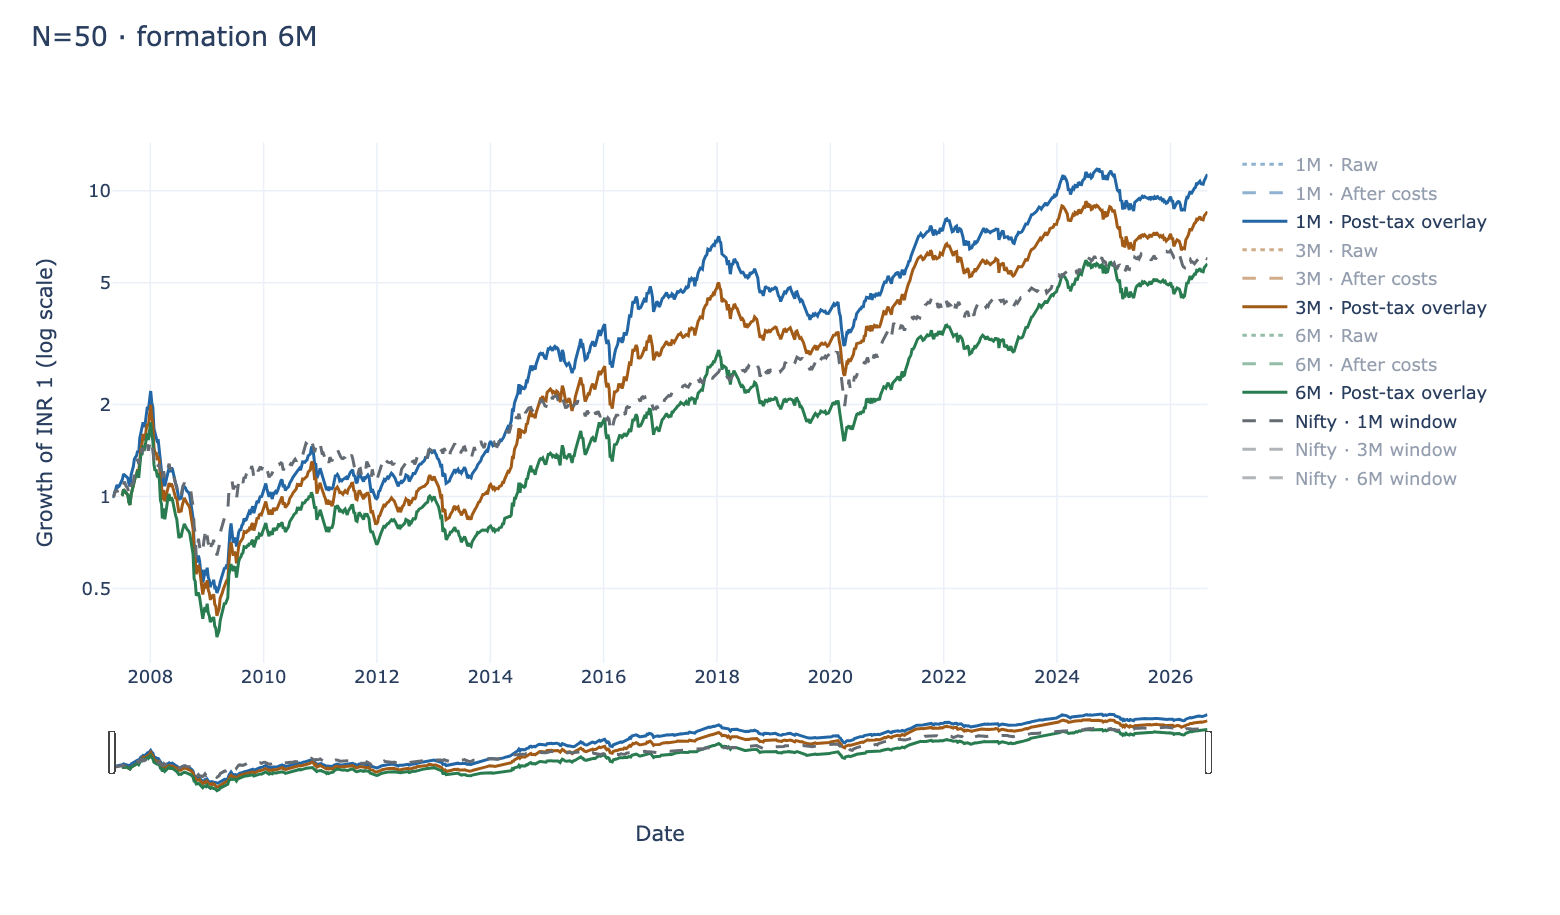

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Raw,16.5%,0.517,-77.6%,10.4%
1M,After costs,15.2%,0.463,-78.0%,10.4%
1M,Post-tax overlay,13.4%,0.382,-78.8%,10.8%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Raw,14.4%,0.421,-78.9%,11.2%
3M,After costs,13.7%,0.390,-79.1%,11.2%
3M,Post-tax overlay,11.9%,0.312,-80.3%,11.3%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%
6M,Raw,11.6%,0.303,-79.3%,11.5%
6M,After costs,11.1%,0.282,-79.5%,11.5%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Raw,17.0%,92.3%,1579
1M,After costs,17.0%,92.8%,1593
3M,Raw,17.4%,93.3%,1643
3M,After costs,17.4%,93.5%,1647
6M,Raw,17.8%,93.2%,1863
6M,After costs,17.8%,93.4%,1940
1M,Post-tax overlay,17.5%,93.7%,1598
3M,Post-tax overlay,17.8%,94.3%,1680
6M,Post-tax overlay,18.2%,94.2%,1966
1M,Nifty 50 price,13.1%,92.4%,1520


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2008-01-07,2009-03-09,2014-09-05,1643,2432,-79.8%
3M,2008-01-07,2009-03-09,2014-11-14,1686,2502,-80.2%
6M,2008-01-07,2009-03-09,2015-12-03,1946,2886,-80.5%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean names at rebalance,Mean cash weight,Scheduled name retention
1M,12,21.85,1.3%,71.0%
1M,24,38.05,1.1%,69.2%
1M,50,74.04,1.0%,70.3%
3M,12,17.90,2.0%,43.6%
3M,24,37.74,1.9%,48.6%
3M,50,69.70,1.7%,47.4%
6M,12,18.87,2.8%,36.2%
6M,24,34.03,3.0%,30.5%
6M,50,70.72,2.0%,32.5%


Rebalance,N,Mean scheduled turnover,All trading charges (INR),Days with stop sales
1M,12,29.7%,"4,830,858.58",0
1M,24,31.1%,"7,122,545.42",0
1M,50,30.7%,"8,917,915.35",0
3M,12,53.7%,"1,549,516.69",0
3M,24,53.3%,"3,213,471.51",0
3M,50,54.2%,"4,091,243.29",0
6M,12,55.0%,"459,624.21",0
6M,24,69.6%,"1,272,209.62",0
6M,50,69.0%,"1,672,556.04",0


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

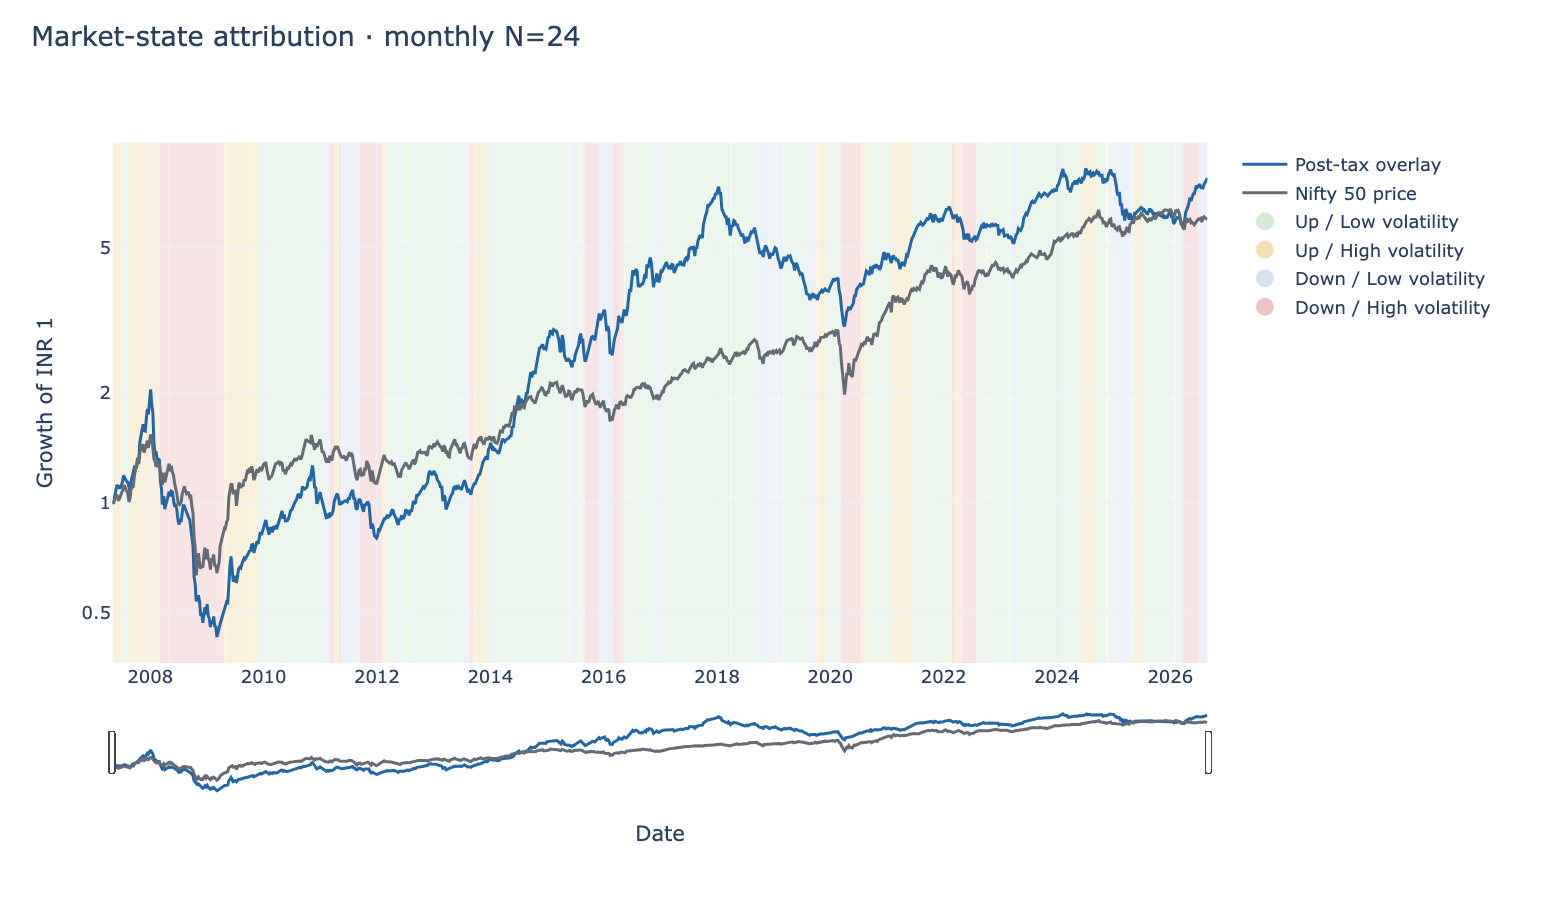

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.02%,1.62%,55.88%
Down / Low volatility,609,-0.04%,1.54%,51.72%
Up / High volatility,720,0.18%,1.46%,58.89%
Up / Low volatility,2694,0.06%,1.17%,55.98%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,5070
1M,24,2007-05-03,2026-08-03,232,8828
1M,50,2007-05-03,2026-08-03,232,17178
3M,12,2007-07-02,2026-07-01,77,1378
3M,24,2007-07-02,2026-07-01,77,2906
3M,50,2007-07-02,2026-07-01,77,5367
6M,12,2007-07-02,2026-07-01,39,736
6M,24,2007-07-02,2026-07-01,39,1327
6M,50,2007-07-02,2026-07-01,39,2758


## Findings

In [16]:
research.conclusion()

Matched reference: [Raw Momentum — 6M — Equal Weight](02_raw_momentum_6m_equal_weight.ipynb). The comparison holds formation, maintenance, frequency and N fixed.